In [1]:
import joblib
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from ml_baselines.modelling.train import get_train_test_data, train_mlp, train_baseline_model
from ml_baselines.modelling.predict import predict_baselines
from ml_baselines.config import Config
from ml_baselines.data import read_agage, read_intem
from ml_baselines.modelling.plot import BaselineLabelledObservations, plot_confusion_matrix

In [2]:
%load_ext autoreload
%autoreload 2
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

In [3]:
cfg = Config()
site = "MHD"

## plotting obs from a trained model

In [4]:
model, _,_  = train_baseline_model("MHD", model_type="random_forest",
                            balance=-1, 
                            model_params={"min_samples_split":10, "max_depth":15, "max_samples":0.8}, sample_weights="auto", return_scores=False, verbose=False)

In [5]:
y, y_pred, metrics = predict_baselines("MHD", model, prediction_mode="validation", prediction_threshold=0.75)

Predicting on validation set for site: MHD with prediction threshold: 0.75
Loading data for site: MHD, period: 2019-2019
Precision: 0.638
Recall: 0.185
F1 Score: 0.287


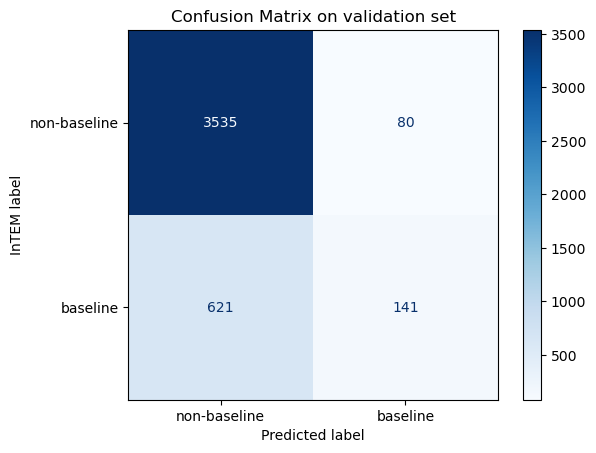

In [10]:
plot_confusion_matrix(y, y_pred, normalise=False, title="Confusion Matrix on validation set")

### load some observations, and predict baselines for the full period for plotting purposes

In [28]:
y, y_pred, metrics = predict_baselines("MHD", model, prediction_mode="full", prediction_threshold=0.85)

Predicting on full set for site: MHD with prediction threshold: 0.85
Loading data for site: MHD, period: 2016-2023
Precision: 0.959
Recall: 0.210
F1 Score: 0.344


In [29]:
site = "MHD"
species = "hfc-134a".lower() #"hfc-134a" 
start_year=2016
end_year=2023

In [30]:
df_agage = read_agage(site, species, start_year=start_year, end_year=end_year)

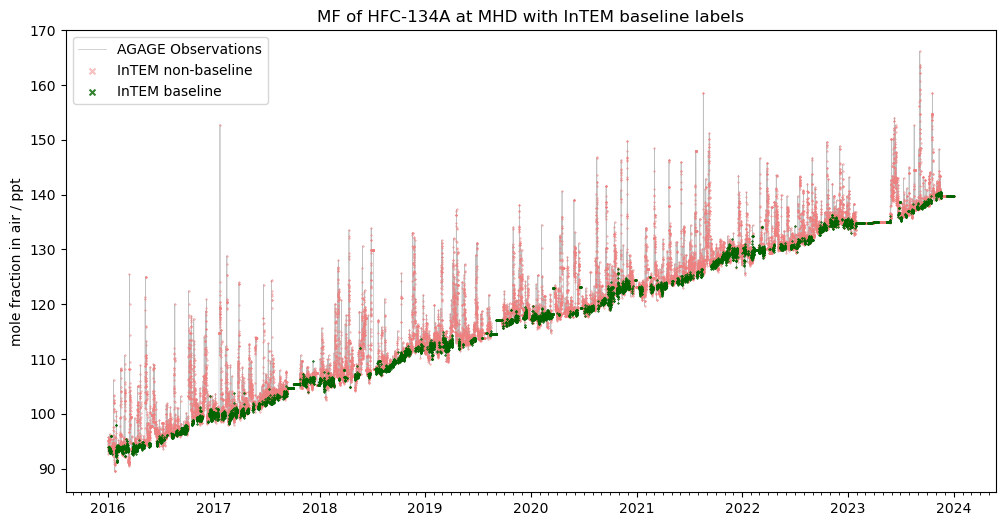

In [31]:
## this class aligns the predictions of the observations and does some plotting
labelled_obs = BaselineLabelledObservations(y, y_pred, df_agage, species=species, site=site)
labelled_obs.plot_obs()  

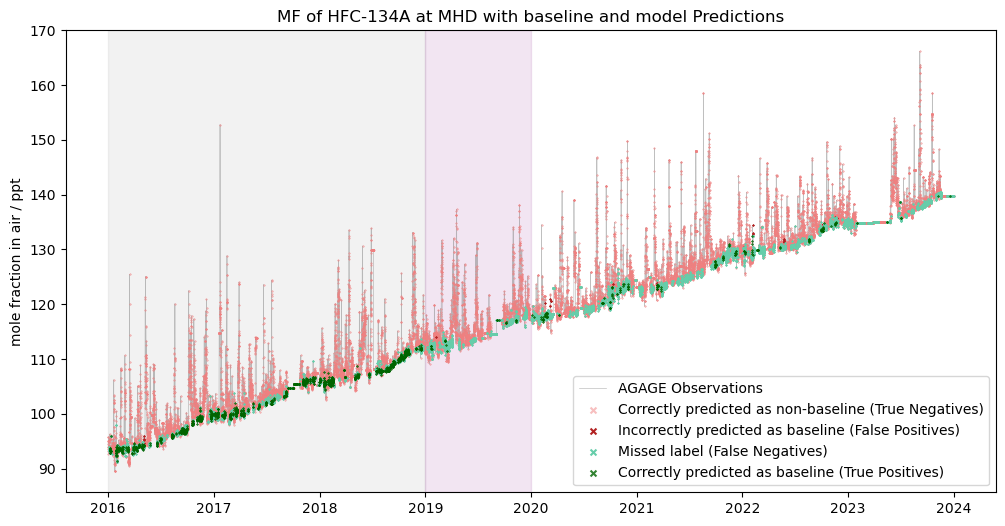

In [32]:
labelled_obs.plot_obs_with_labels(plot_true_negatives=True)

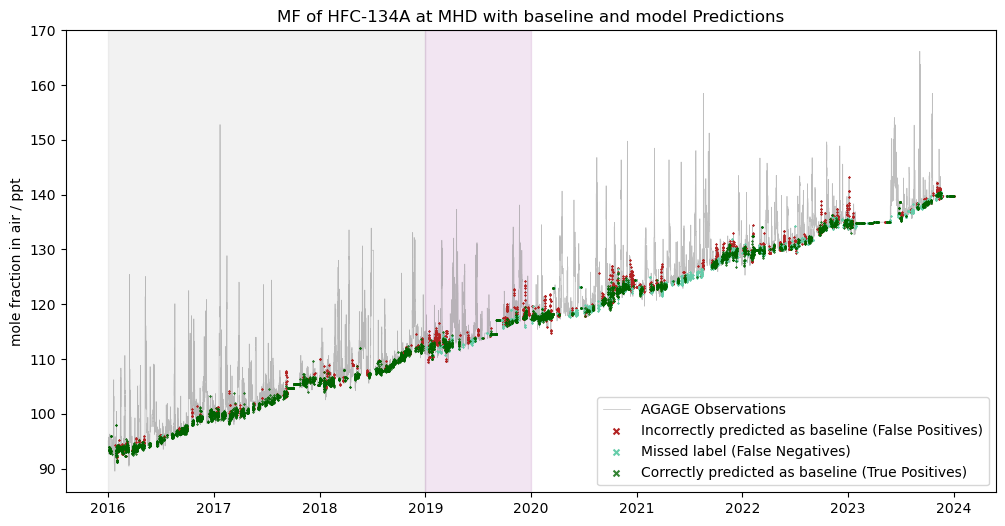

In [37]:
# i actually think that plotting the true negatives is helpful! but for comparison
labelled_obs.plot_obs_with_labels(plot_true_negatives=False)

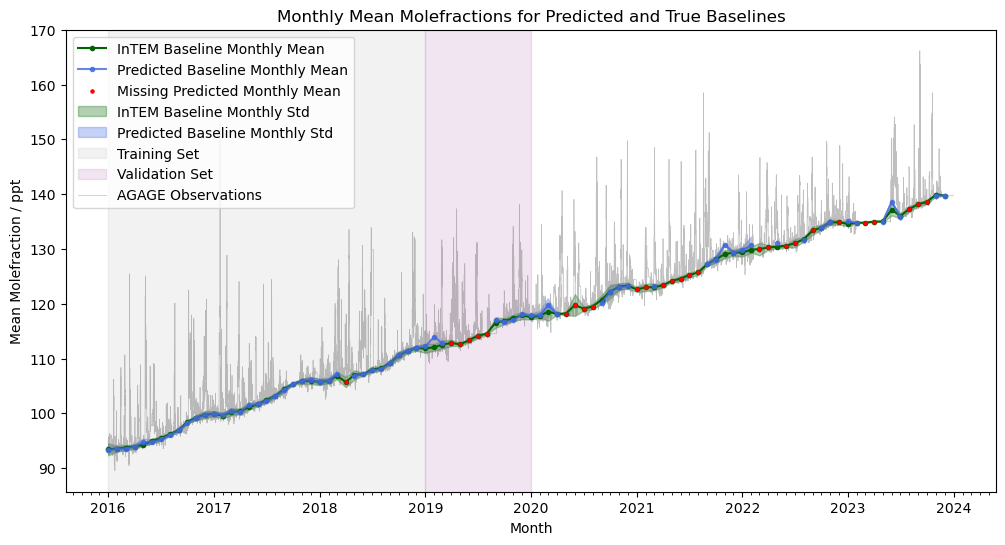

In [85]:
labelled_obs.plot_monthly_means()

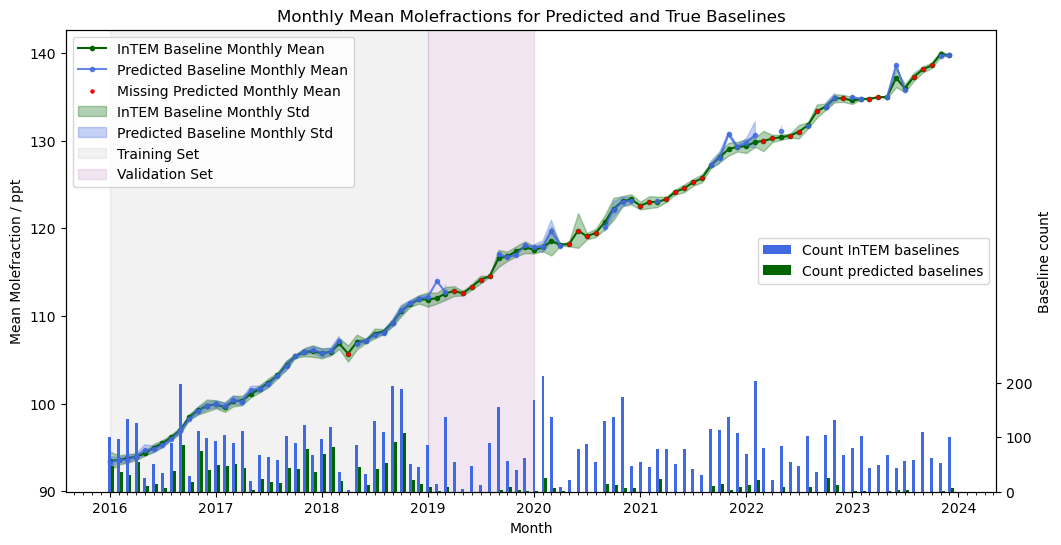

In [84]:
## the anomalies are more obvious if we only plot the monthly means
labelled_obs.plot_monthly_means(plot_obs=False, plot_count_hist=True )

## other experiments

In [ ]:
params_dict = {'activation': 'relu', 'alpha': 0.0001, 'batch_size': 50, 'early_stopping': True, 'hidden_layer_sizes': (100,), 'learning_rate': 'constant', 'max_iter': 1000, 'solver': 'adam'}
model, X, y = train_baseline_model(site, model_type="mlp", model_params=params_dict, return_scores=False, verbose=True)

In [4]:
model, x, y = train_baseline_model("MHD", model_type="random_forest",
                        balance=-1, 
                        model_params={"min_samples_split":10, "max_depth":15, "max_samples":0.8}, sample_weights=10)

Training random_forest model for site: MHD
Calculating sample weights...
Assigning baseline sample weight: 10.000 and non-baseline sample weight: 1.000
Number of training points: 13149
... number of baseline points: 3174 (24.1%)
... fitting
... predicting
Precision on Training Set = 0.674
Precision on Validation Set = 0.428
Precision on Test Set = 0.524
Recall on Training Set = 1.000
Recall on Validation Set = 0.744
Recall on Test Set = 0.738
F1 Score on Training Set = 0.805
F1 Score on Validation Set = 0.543
F1 Score on Test Set = 0.613


In [4]:
model, x, y = train_baseline_model("MHD", model_type="gradient_boosting",
                        balance=-1, 
                        model_params={"min_samples_split":10, "max_depth":15, "max_features":"sqrt", "subsample":0.8}, sample_weights=10)

Training gradient_boosting model for site: MHD
Calculating sample weights...
Assigning baseline sample weight: 10.000 and non-baseline sample weight: 1.000
Number of training points: 13149
... number of baseline points: 3174 (24.1%)
... fitting
... predicting
Precision on Training Set = 1.000
Precision on Validation Set = 0.479
Precision on Test Set = 0.567
Recall on Training Set = 1.000
Recall on Validation Set = 0.591
Recall on Test Set = 0.555
F1 Score on Training Set = 1.000
F1 Score on Validation Set = 0.529
F1 Score on Test Set = 0.561


In [12]:
metric_dict = {}
thr_values = [0.25, 0.5, 0.75, 0.8, 0.9]
for threshold in thr_values:
    y, y_pred, metrics = predict_baselines("MHD", model, prediction_mode="validation", prediction_threshold=threshold)
    metric_dict[threshold] = metrics

Predicting on validation set for site: MHD with time shifts: [6] and prediction threshold: 0.25
Precision: 0.338
Recall: 0.945
F1 Score: 0.498
Predicting on validation set for site: MHD with time shifts: [6] and prediction threshold: 0.5
Precision: 0.428
Recall: 0.744
F1 Score: 0.543
Predicting on validation set for site: MHD with time shifts: [6] and prediction threshold: 0.75
Precision: 0.524
Recall: 0.421
F1 Score: 0.467
Predicting on validation set for site: MHD with time shifts: [6] and prediction threshold: 0.8
Precision: 0.567
Recall: 0.333
F1 Score: 0.420
Predicting on validation set for site: MHD with time shifts: [6] and prediction threshold: 0.9
Precision: 0.681
Recall: 0.081
F1 Score: 0.145


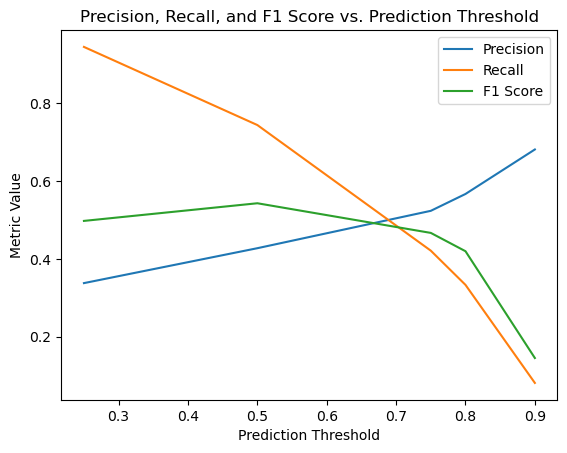

In [13]:
plt.plot(thr_values, [metric_dict[thr]["precision"] for thr in thr_values], label="Precision")
plt.plot(thr_values, [metric_dict[thr]["recall"] for thr in thr_values], label="Recall")
plt.plot(thr_values, [metric_dict[thr]["f1"] for thr in thr_values], label="F1 Score")
plt.xlabel("Prediction Threshold")
plt.ylabel("Metric Value")
plt.title("Precision, Recall, and F1 Score vs. Prediction Threshold")
plt.legend()

In [35]:
weights_dict = {}
weights_list = [1,2,4,10,20]
for weight in weights_list:
    _, _, _, metrics = train_baseline_model("MHD", model_type="random_forest",
                            balance=-1, 
                            model_params={"min_samples_split":10, "max_depth":15, "max_samples":0.8}, sample_weights=weight, return_scores=True, verbose=False, prediction_threshold=0.75)
    weights_dict[weight] = metrics

Using custom prediction threshold of 0.75 instead of default 0.5
Using custom prediction threshold of 0.75 instead of default 0.5
Using custom prediction threshold of 0.75 instead of default 0.5
Using custom prediction threshold of 0.75 instead of default 0.5
Using custom prediction threshold of 0.75 instead of default 0.5


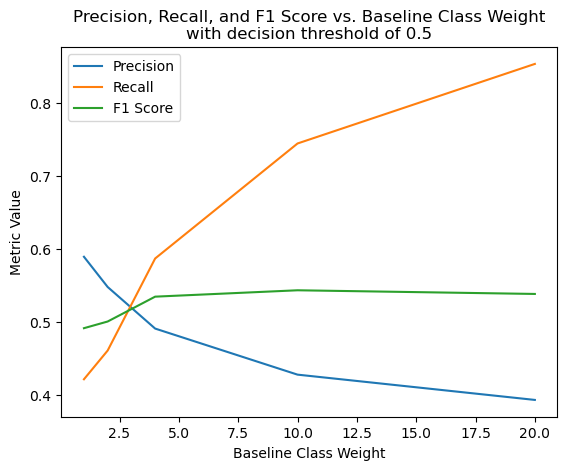

In [33]:
plt.plot(weights_list, [weights_dict[w]["precision_val"] for w in weights_list], label="Precision")
plt.plot(weights_list, [weights_dict[w]["recall_val"] for w in weights_list], label="Recall")
plt.plot(weights_list, [weights_dict[w]["f1_val"] for w in weights_list], label="F1 Score")
plt.xlabel("Baseline Class Weight")
plt.ylabel("Metric Value")
plt.title("Precision, Recall, and F1 Score vs. Baseline Class Weight\nwith decision threshold of 0.5")
plt.legend()

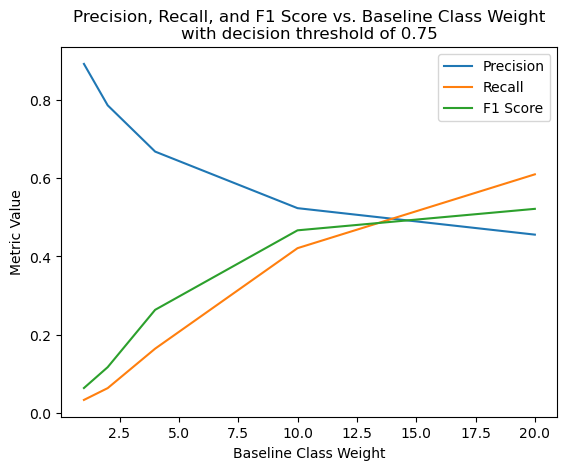

In [36]:
plt.plot(weights_list, [weights_dict[w]["precision_val"] for w in weights_list], label="Precision")
plt.plot(weights_list, [weights_dict[w]["recall_val"] for w in weights_list], label="Recall")
plt.plot(weights_list, [weights_dict[w]["f1_val"] for w in weights_list], label="F1 Score")
plt.xlabel("Baseline Class Weight")
plt.ylabel("Metric Value")
plt.title("Precision, Recall, and F1 Score vs. Baseline Class Weight\nwith decision threshold of 0.75")
plt.legend()

In [38]:
model, _,_  = train_baseline_model("MHD", model_type="random_forest",
                            balance=-1, 
                            model_params={"min_samples_split":10, "max_depth":15, "max_samples":0.8}, sample_weights="auto", return_scores=False, verbose=False)

In [ ]:
y, y_pred, metrics = predict_baselines("MHD", model, prediction_mode="validation", prediction_threshold=0.75)

Predicting on validation set for site: MHD with time shifts: [6] and prediction threshold: 0.75
Precision: 0.638
Recall: 0.185
F1 Score: 0.287


In [5]:
y, y_pred, metrics = predict_baselines("MHD", model, prediction_mode="test", prediction_threshold=0.5)

Predicting on test set for site: MHD with time shifts: [6] and prediction threshold: 0.5
Precision: 0.524
Recall: 0.738
F1 Score: 0.613
